In [2]:
import pandas as pd
import numpy as np
import sklearn
import re
import nltk
import time
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve
from transformers import AutoModel, AutoTokenizer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, label_binarize

def print_evaluation(y_true, y_pred, y_score=None, labels=None, model_name=None):
    if model_name:
        print(f"\n=== Evaluation for {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print("Confusion Matrix:")
    print(cm)
    try:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap='Blues', values_format='d')
        plt.title(f"Confusion Matrix - {model_name}" if model_name else "Confusion Matrix")
        plt.show()
    except Exception:
        pass
    if y_score is not None:
        try:
            if isinstance(y_score, list):
                y_score = np.array(y_score)
            if y_score.ndim == 1 or (y_score.ndim == 2 and y_score.shape[1] == 1):
                y_score = np.array(y_score).ravel()
                auc = roc_auc_score(y_true, y_score)
                fpr, tpr, _ = roc_curve(y_true, y_score)
                plt.figure()
                plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
                plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.title(f'ROC Curve - {model_name}' if model_name else 'ROC Curve')
                plt.legend(loc='lower right')
                plt.grid(True)
                plt.show()
            else:
                label_values = labels if labels is not None else np.unique(np.concatenate([y_true, y_pred]))
                y_true_bin = label_binarize(y_true, classes=label_values)
                auc = roc_auc_score(y_true_bin, y_score, average='macro', multi_class='ovr')
                plt.figure(figsize=(8, 6))
                for i, class_label in enumerate(label_values):
                    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                    plt.plot(fpr, tpr, label=f'{class_label} (AUC = {roc_auc_score(y_true_bin[:, i], y_score[:, i]):.4f})')
                plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.title(f'ROC Curve - {model_name}' if model_name else 'ROC Curve')
                plt.legend(loc='lower right')
                plt.grid(True)
                plt.show()
            print("ROC AUC:", auc)
        except Exception as e:
            print("ROC AUC could not be computed:", e)

from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

MODEL_NAME = "bert-base-uncased"

c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Ensure reproducability

In [3]:
import numpy as np
import torch
import random
import os

def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_all_seeds(SEED)
print(f"All random seeds set to {SEED} for reproducibility.")

All random seeds set to 42 for reproducibility.


## Accuracy dict

In [4]:
svm_tfidf_balanced_scores_SMOTE = []
logistic_tfidf_balanced_scores_SMOTE = []

svm_bert_balanced_scores_SMOTE = []
logistic_bert_balanced_scores_SMOTE = []

svm_tfidf_imbalanced_scores_SMOTE = []
logistic_tfidf_imbalanced_scores_SMOTE = []

svm_bert_imbalanced_scores_SMOTE = []
logistic_bert_imbalanced_scores_SMOTE = []


svm_tfidf_balanced_scores = []
logistic_tfidf_balanced_scores = []

svm_bert_balanced_scores = []
logistic_bert_balanced_scores = []

svm_tfidf_imbalanced_scores = []
logistic_tfidf_imbalanced_scores = []

svm_bert_imbalanced_scores = []
logistic_bert_imbalanced_scores = []

results = {
    'TF-IDF + SVM (Balanced)': svm_tfidf_balanced_scores,
    'TF-IDF + Logistic (Balanced)': logistic_tfidf_balanced_scores,

    'BERT embed + SVM (Balanced)': svm_bert_balanced_scores,
    'BERT embed + Logistic (Balanced)': logistic_bert_balanced_scores,

    'TF-IDF + SVM (Imbalanced)': svm_tfidf_imbalanced_scores,
    'TF-IDF + Logistic (Imbalanced)': logistic_tfidf_imbalanced_scores,

    'BERT embed + SVM (Imbalanced)': svm_bert_imbalanced_scores,
    'BERT embed + Logistic (Imbalanced)': logistic_bert_imbalanced_scores
}

results_SMOTE = {
    'TF-IDF + SVM (Balanced)': svm_tfidf_balanced_scores_SMOTE,
    'TF-IDF + Logistic (Balanced)': logistic_tfidf_balanced_scores_SMOTE,
    
    'BERT embed + SVM (Balanced)': svm_bert_balanced_scores_SMOTE,
    'BERT embed + Logistic (Balanced)': logistic_bert_balanced_scores_SMOTE,
    
    'TF-IDF + SVM (Imbalanced)': svm_tfidf_imbalanced_scores_SMOTE,
    'TF-IDF + Logistic (Imbalanced)': logistic_tfidf_imbalanced_scores_SMOTE,
    'BERT embed + SVM (Imbalanced)': svm_bert_imbalanced_scores_SMOTE,
    'BERT embed + Logistic (Imbalanced)': logistic_bert_imbalanced_scores_SMOTE}

## Simple Normalization

In [5]:
medical_normalization = {

    # Fever
    "high temperature": "fever",
    "body temperature": "fever",
    "hot body": "fever",
    "mild fever": "fever",
    "high fever": "fever",

    # Breathing
    "difficulty breathing": "dyspnea",
    "shortness of breath": "dyspnea",
    "trouble breathing": "dyspnea",
    "can't breathe": "dyspnea",
    "breathlessness": "dyspnea",

    # Chest
    "pain in chest": "chest pain",
    "chest hurts": "chest pain",
    "tight chest": "chest pain",

    # Stomach
    "stomach ache": "abdominal pain",
    "belly pain": "abdominal pain",
    "pain in stomach": "abdominal pain",

    # Vomit / nausea
    "throwing up": "vomiting",
    "feel like vomiting": "nausea",
    "feeling sick": "nausea",

    # Head
    "head hurts": "headache",
    "migraine pain": "headache",

    # Skin
    "skin rash": "rash",
    "red spots": "rash",
    "itchy skin": "itching",

    # Weakness
    "feeling weak": "fatigue",
    "very tired": "fatigue",
    "low energy": "fatigue",

    # Blood pressure / sugar
    "high blood pressure": "hypertension",
    "high blood sugar": "diabetes",

    # Common abbreviations
    "bp": "blood pressure",
    "sob": "dyspnea",
    "mi": "myocardial infarction"
}


def normalize_medical_text(text):

    text = str(text).lower()

    # Replace medical phrases
    for phrase, normalized in medical_normalization.items():

        text = re.sub(
            r'\b' + re.escape(phrase) + r'\b',
            normalized,
            text
        )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

## Load and preprocess dataset

In [6]:
df = pd.read_csv('Symptom2Disease.csv')
X = df['text']
Y = df['label']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)
X_train = X_train.apply(normalize_medical_text)
X_test = X_test.apply(normalize_medical_text)

##### Testing smote performance with imbalanced dataset

In [7]:
train_df = pd.DataFrame({
    'text': X_train,
    'label': Y_train
})

# ==========================================
# Create imbalanced training set
# ==========================================
imbalanced_data = []

labels = train_df['label'].unique()

for i, label in enumerate(labels):

    class_df = train_df[train_df['label'] == label]

    # Keep full samples for first class
    if i == 0:

        sampled_df = class_df

    # Reduce other classes
    else:

        sampled_df = resample(
            class_df,
            replace=False,
            n_samples=max(5, int(len(class_df) * 0.3)),
            random_state=42
        )

    imbalanced_data.append(sampled_df)

# ==========================================
# Combine and shuffle
# ==========================================
imbalanced_df = pd.concat(imbalanced_data)

imbalanced_df = imbalanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ==========================================
# Final train/test data
# ==========================================
X_train_imbalanced = imbalanced_df['text'].apply(normalize_medical_text)

Y_train_imbalanced = imbalanced_df['label']

X_test = X_test.apply(normalize_medical_text)

# ==========================================
# Check distribution
# ==========================================
print("\nImbalanced class distribution:\n")
print(Y_train_imbalanced.value_counts())


Imbalanced class distribution:

label
Chicken pox                        40
Impetigo                           12
urinary tract infection            12
Dengue                             12
Pneumonia                          12
Jaundice                           12
Dimorphic Hemorrhoids              12
Cervical spondylosis               12
peptic ulcer disease               12
Acne                               12
diabetes                           12
Common Cold                        12
gastroesophageal reflux disease    12
Psoriasis                          12
Migraine                           12
Hypertension                       12
Varicose Veins                     12
Malaria                            12
Typhoid                            12
Arthritis                          12
Bronchial Asthma                   12
drug reaction                      12
allergy                            12
Fungal infection                   12
Name: count, dtype: int64


## Preprocessing

In [8]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

stop_words = set(stopwords.words('english'))
stemmer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return 'a'  # adjective
    elif treebank_tag.startswith('V'):
        return 'v'  # verb
    elif treebank_tag.startswith('N'):
        return 'n'  # noun
    elif treebank_tag.startswith('R'):
        return 'r'  # adverb
    else:
        return 'n'  # default to noun

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)

    contractions = {
        "i'm": "i am",
        "i've": "i have",
        "i'll": "i will",
        "i'd": "i would",
        "you're": "you are",
        "you've": "you have",
        "you'll": "you will",
        "you'd": "you would",
        "he's": "he is",
        "she's": "she is",
        "it's": "it is",
        "we're": "we are",
        "we've": "we have",
        "we'll": "we will",
        "they're": "they are",
        "they've": "they have",
        "they'll": "they will",
        "that's": "that is",
        "there's": "there is",
        "can't": "cannot",
        "won't": "will not",
        "don't": "do not",
        "didn't": "did not",
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "shouldn't": "should not",
        "couldn't": "could not",
        "wouldn't": "would not",
        "haven't": "have not",
        "hasn't": "has not",
        "hadn't": "had not"
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text)

    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # POS tagging and lemmatization
    tagged_words = pos_tag(words)
    words = [stemmer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_words]
    
    text = ' '.join(words)
    
    return text

X_train_tfidf = X_train.apply(clean_text)
X_test_tfidf = X_test.apply(clean_text)
X_train_imbalanced = X_train_imbalanced.apply(clean_text)
print('Sample cleaned text:')
print(X_train_tfidf.iloc[0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MS1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MS1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\MS1\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Sample cleaned text:
feel really nauseous uneasy sure might see rash arm legs lose appetite feel exhaust every day


## BERT cleaning

In [9]:
def clean_text_bert(text):
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_train_bert = X_train.apply(clean_text_bert)
X_test_bert = X_test.apply(clean_text_bert)
X_train_imbalanced_bert = X_train_imbalanced.apply(clean_text_bert)
print('Sample BERT cleaned text:')
print(X_train_bert.iloc[0])

Sample BERT cleaned text:
i'm feeling really nauseous and uneasy. i'm not sure what it might be. i've seen rashes on my arms and legs. i have lost my appetite and feel exhausted every day.


## Models Used

In [10]:
base_model = BertModel.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
svm_model_non_SMOTE = LinearSVC()
svm_model_non_SMOTE_BERT = LinearSVC()
svm_model_with_SMOTE = LinearSVC()
svm_model_with_SMOTE_BERT = LinearSVC()
logistic_model_non_SMOTE = LogisticRegression(max_iter=1000)
logistic_model_with_SMOTE = LogisticRegression(max_iter=1000)
logistic_model_non_SMOTE_BERT = LogisticRegression(max_iter=1000)
logistic_model_with_SMOTE_BERT = LogisticRegression(max_iter=1000)

## SMOTE and feature extract for RNN, SVM (TF-idf)


In [11]:
vectorizer= TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train_tfidf).toarray()
X_train_vec_imbalanced = vectorizer.transform(X_train_imbalanced).toarray()
X_test_vec = vectorizer.transform(X_test_tfidf).toarray()

target_counts = {label: int(count * 1.5) for label, count in Y_train.value_counts().items()}
smote = SMOTE(sampling_strategy=target_counts, random_state=42)
smote_imbalanced = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train_vec, Y_train)
X_train_resampled_imbalanced, Y_train_resampled_imbalanced = smote_imbalanced.fit_resample(X_train_vec_imbalanced, Y_train_imbalanced)

# print('Original train size:', len(Y_train))
# print('Resampled train size:', len(Y_train_resampled))
# print('Original class counts:\n', Y_train.value_counts())
# print('Resampled class counts:\n', Y_train_resampled.value_counts())

## Feature extract and SMOTE with BERT embedding

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

bert_model.to(device)
bert_model.eval()


def get_bert_embeddings(texts, batch_size=32):

    embeddings = []

    # Convert all inputs to strings
    texts = [str(text) for text in texts]

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=64
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():

            outputs = bert_model(**inputs)

            token_embeddings = outputs.last_hidden_state
            attention_mask = inputs['attention_mask']

            # Mean Pooling
            mask = attention_mask.unsqueeze(-1).expand(
                token_embeddings.size()
            ).float()

            masked_embeddings = token_embeddings * mask

            summed = masked_embeddings.sum(dim=1)

            counts = mask.sum(dim=1)

            batch_embeddings = summed / counts

        embeddings.extend(batch_embeddings.cpu().numpy())

    return np.array(embeddings)

In [13]:
start_time = time.time()

X_train_embeddings = get_bert_embeddings(X_train_bert)

X_train_embeddings_imbalanced = get_bert_embeddings(
    X_train_imbalanced
)

X_test_embeddings = get_bert_embeddings(X_test_bert)

end_time = time.time()

print(f"Embed Duration: {end_time - start_time:.2f} seconds")

Embed Duration: 47.83 seconds


##### SMOTE aplied on BERT embedded dataset

In [14]:
target_counts = {label: int(count * 1.5) for label, count in Y_train.value_counts().items()}
smote = SMOTE(sampling_strategy=target_counts, random_state=42)

X_train_resampled_BERT, Y_train_resampled_BERT = smote.fit_resample(X_train_embeddings,Y_train)
X_train_resampled_BERT_imbalanced, Y_train_resampled_BERT_imbalanced = smote.fit_resample(X_train_embeddings_imbalanced,Y_train_imbalanced)

## SVM Model

##### TF-idf feature extract (Without SMOTE)

###### on the imbalanced dataset

SVM Accuracy: 0.8583
Training Duration: 0.02 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.83      1.00      0.91        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.48      1.00      0.65        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.40      0.57        10
          Dimorphic Hemorrhoids       0.91      1.00      0.95        10
               Fungal infection       0.91      1.00      0.95        10
                   Hypertension       0.83      1.00      0.91        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       1.00   

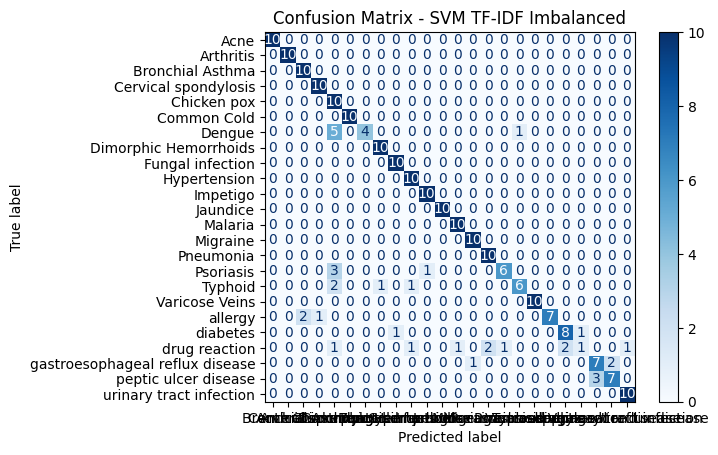

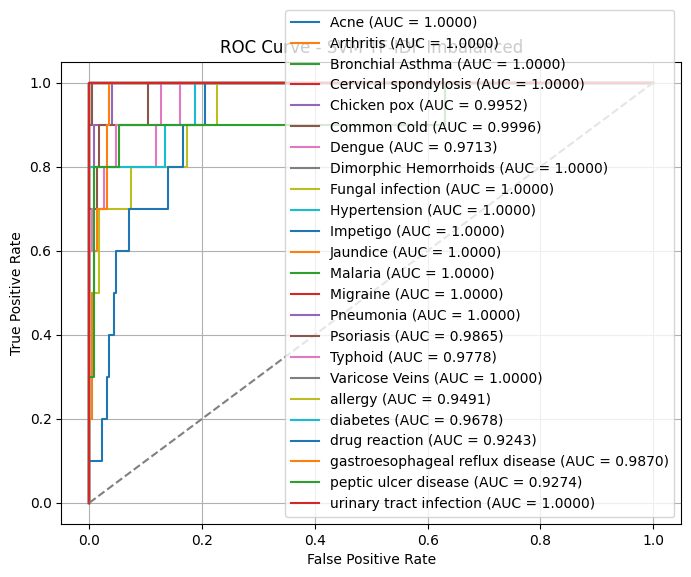

ROC AUC: 0.9869202898550725


In [15]:
start_time = time.time()
svm_model_non_SMOTE.fit(X_train_vec_imbalanced, Y_train_imbalanced)
end_time = time.time()
Y_pred = svm_model_non_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
svm_tfidf_imbalanced_scores.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_non_SMOTE.decision_function(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM TF-IDF Imbalanced"
)


###### on the balanced dataset

SVM Accuracy: 0.9583
Training Duration: 0.03 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.91      1.00      0.95        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.80      0.89        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00   

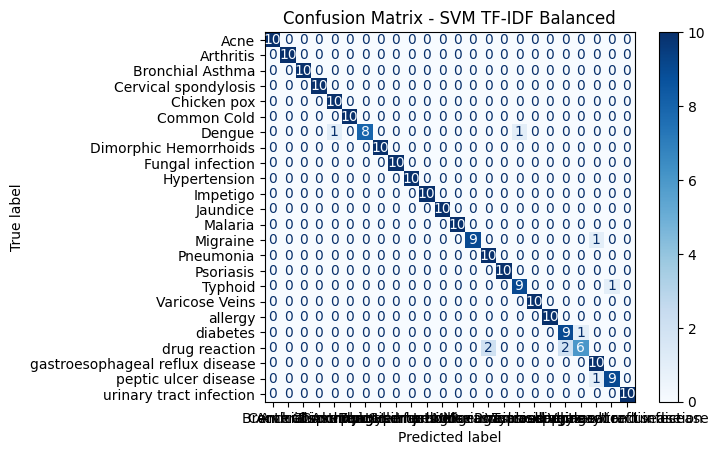

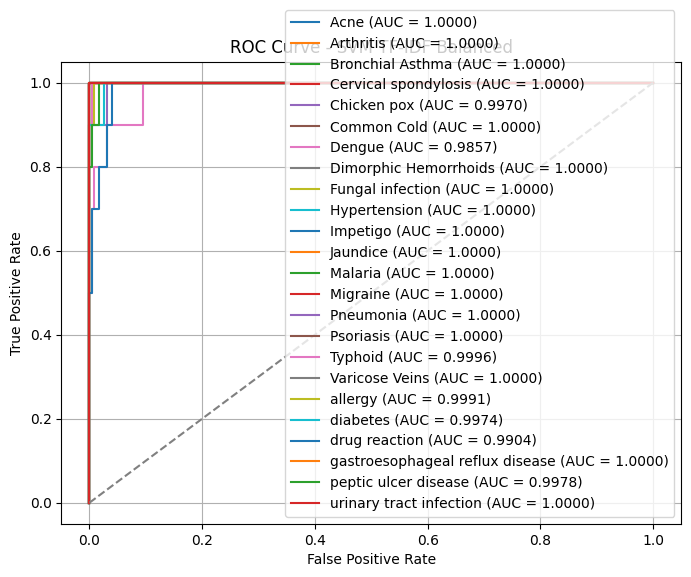

ROC AUC: 0.998623188405797


In [16]:
start_time = time.time()
svm_model_non_SMOTE.fit(X_train_vec,Y_train)
end_time = time.time()
Y_pred = svm_model_non_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
svm_tfidf_balanced_scores.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_non_SMOTE.decision_function(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM TF-IDF Balanced"
)


##### BERT feature extract (Without SMOTE)

###### Imbalanced

SVM Accuracy: 0.4208
Training Duration: 0.90 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      0.70      0.82        10
                      Arthritis       0.90      0.90      0.90        10
               Bronchial Asthma       0.67      0.20      0.31        10
           Cervical spondylosis       1.00      0.10      0.18        10
                    Chicken pox       0.24      0.90      0.38        10
                    Common Cold       0.00      0.00      0.00        10
                         Dengue       0.00      0.00      0.00        10
          Dimorphic Hemorrhoids       0.89      0.80      0.84        10
               Fungal infection       0.71      1.00      0.83        10
                   Hypertension       1.00      0.30      0.46        10
                       Impetigo       1.00      0.50      0.67        10
                       Jaundice       1.00   

c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

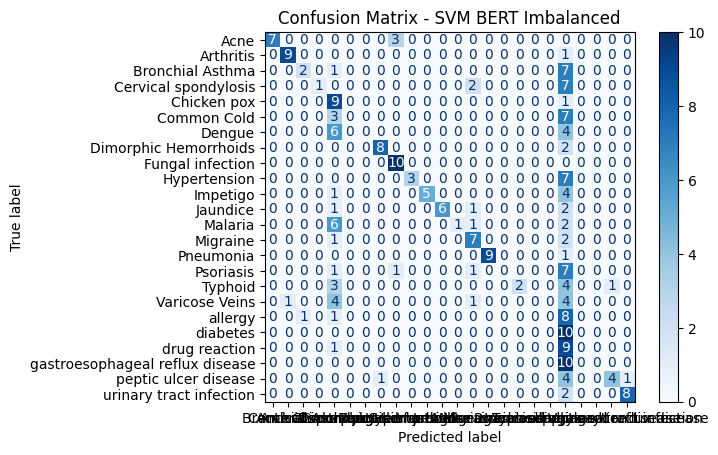

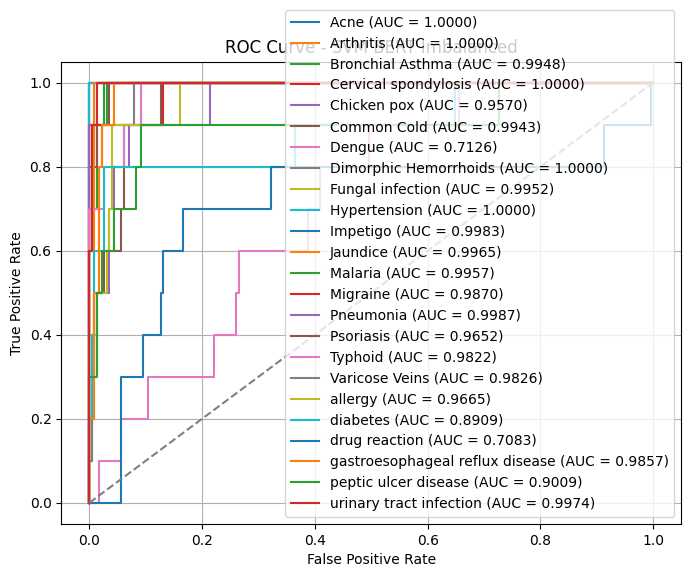

ROC AUC: 0.958731884057971


In [17]:
start_time = time.time()
svm_model_non_SMOTE_BERT.fit(X_train_embeddings_imbalanced,Y_train_imbalanced)
end_time = time.time()
Y_pred = svm_model_non_SMOTE_BERT.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
svm_bert_imbalanced_scores.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_non_SMOTE_BERT.decision_function(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM BERT Imbalanced"
)


###### Balanced

SVM Accuracy: 0.9667
Training Duration: 0.94 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.67      0.80      0.73        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       1.00   

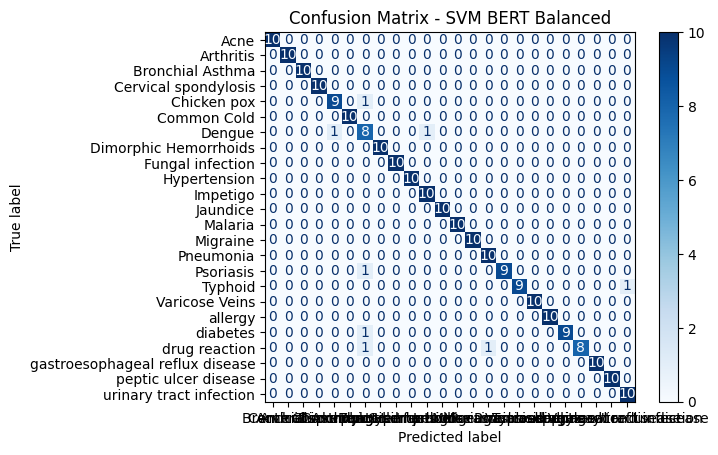

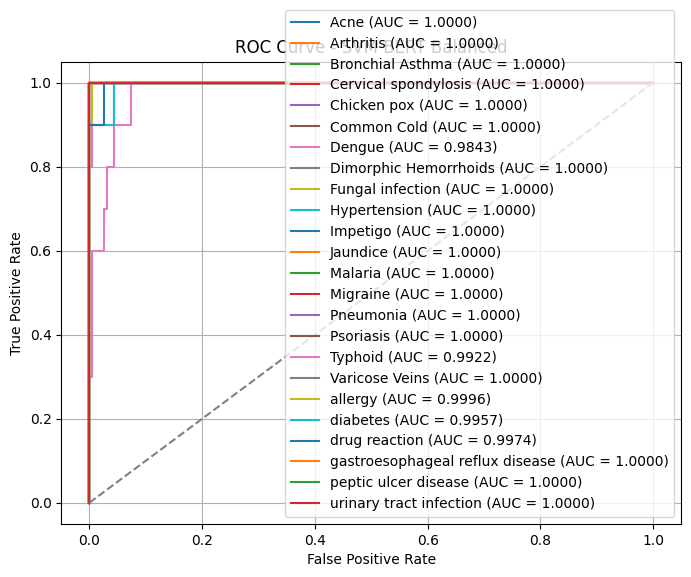

ROC AUC: 0.9987137681159419


In [18]:
start_time = time.time()
svm_model_non_SMOTE_BERT.fit(X_train_embeddings,Y_train)
end_time = time.time()
Y_pred = svm_model_non_SMOTE_BERT.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
svm_bert_balanced_scores.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_non_SMOTE_BERT.decision_function(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM BERT Balanced"
)


##### TF-idf feature extract (With SMOTE)

###### On the imbalanced dataset

SVM Accuracy: 0.8667
Training Duration: 0.04 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.62      1.00      0.77        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.83      0.50      0.62        10
          Dimorphic Hemorrhoids       0.91      1.00      0.95        10
               Fungal infection       0.91      1.00      0.95        10
                   Hypertension       0.91      1.00      0.95        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       1.00   

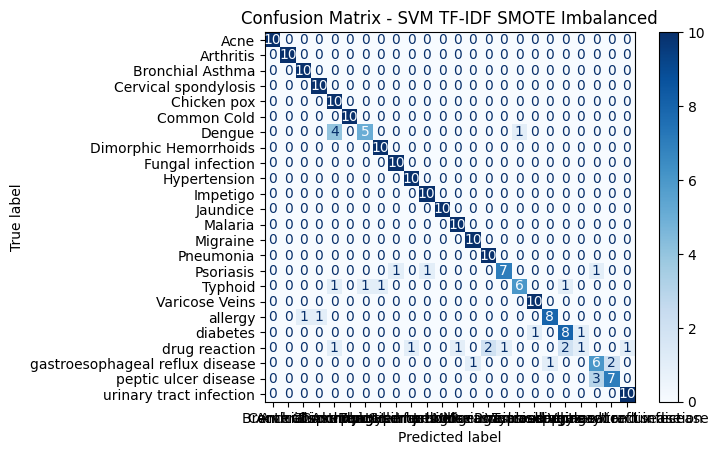

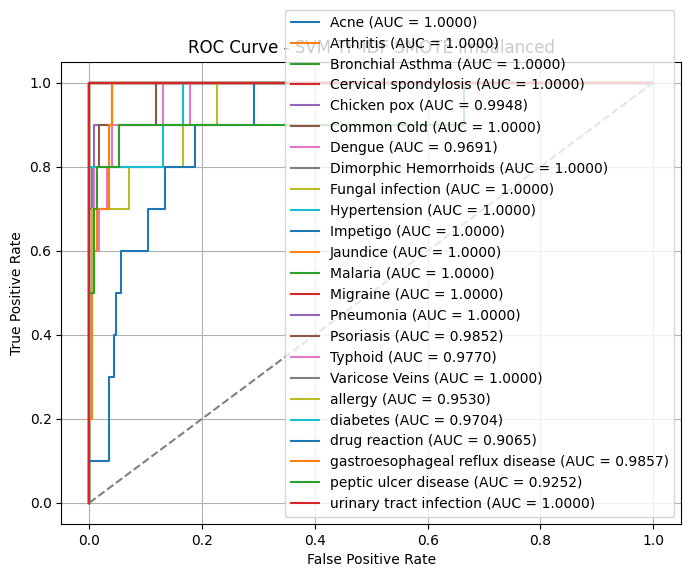

ROC AUC: 0.9861231884057972


In [19]:
start_time = time.time()
svm_model_with_SMOTE.fit(X_train_resampled_imbalanced, Y_train_resampled_imbalanced)
end_time = time.time()
Y_pred = svm_model_with_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
svm_tfidf_imbalanced_scores_SMOTE.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_with_SMOTE.decision_function(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM TF-IDF SMOTE Imbalanced"
)


###### Balanced

SVM Accuracy: 0.9542
Training Duration: 0.06 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.80      0.89        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00   

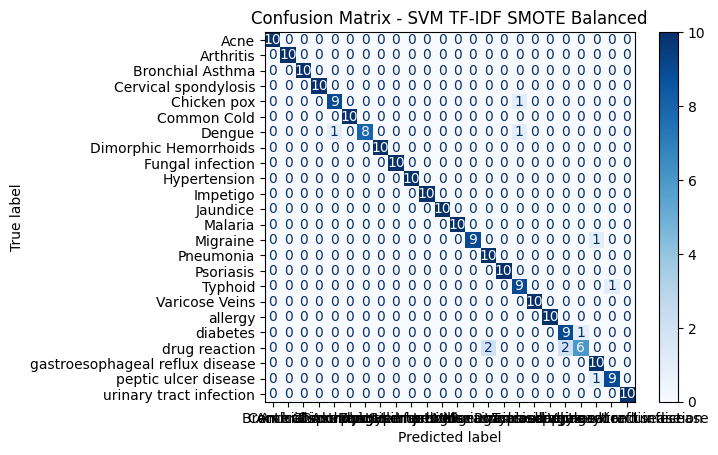

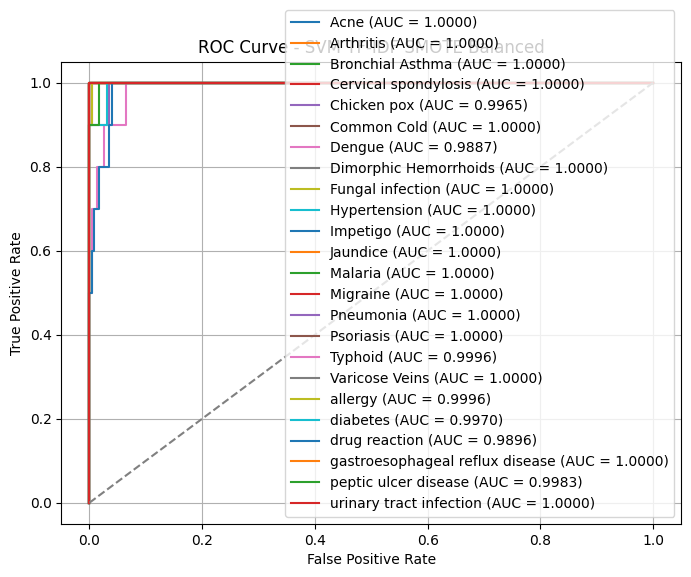

ROC AUC: 0.998713768115942


In [20]:
start_time = time.time()
svm_model_with_SMOTE.fit(X_train_resampled, Y_train_resampled)
end_time = time.time()
Y_pred = svm_model_with_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
svm_tfidf_balanced_scores_SMOTE.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_with_SMOTE.decision_function(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM TF-IDF SMOTE Balanced"
)


##### BERT feature extract (With SMOTE)

###### Imbalanced

SVM Accuracy: 0.4125
Training Duration: 2.44 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      0.70      0.82        10
                      Arthritis       0.90      0.90      0.90        10
               Bronchial Asthma       0.50      0.10      0.17        10
           Cervical spondylosis       1.00      0.10      0.18        10
                    Chicken pox       0.25      0.90      0.39        10
                    Common Cold       0.00      0.00      0.00        10
                         Dengue       0.00      0.00      0.00        10
          Dimorphic Hemorrhoids       1.00      0.80      0.89        10
               Fungal infection       0.77      1.00      0.87        10
                   Hypertension       1.00      0.30      0.46        10
                       Impetigo       1.00      0.50      0.67        10
                       Jaundice       1.00   

c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

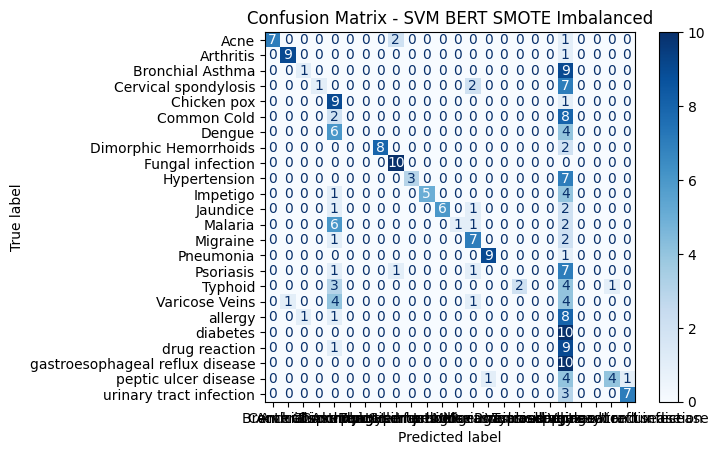

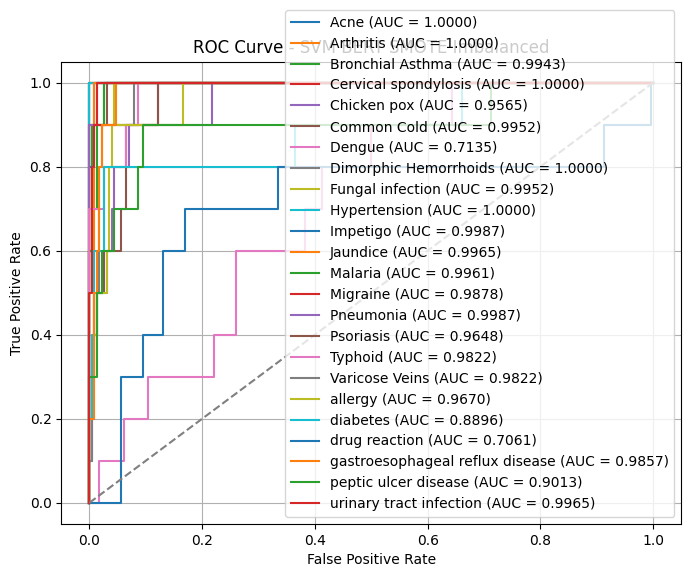

ROC AUC: 0.958659420289855


In [21]:
start_time = time.time()
svm_model_with_SMOTE_BERT.fit(X_train_resampled_BERT_imbalanced,Y_train_resampled_BERT_imbalanced)
end_time = time.time()
Y_pred = svm_model_with_SMOTE_BERT.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
svm_bert_imbalanced_scores_SMOTE.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_with_SMOTE_BERT.decision_function(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM BERT SMOTE Imbalanced"
)


###### Balanced

SVM Accuracy: 0.9667
Training Duration: 1.81 seconds

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.67      0.80      0.73        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       1.00   

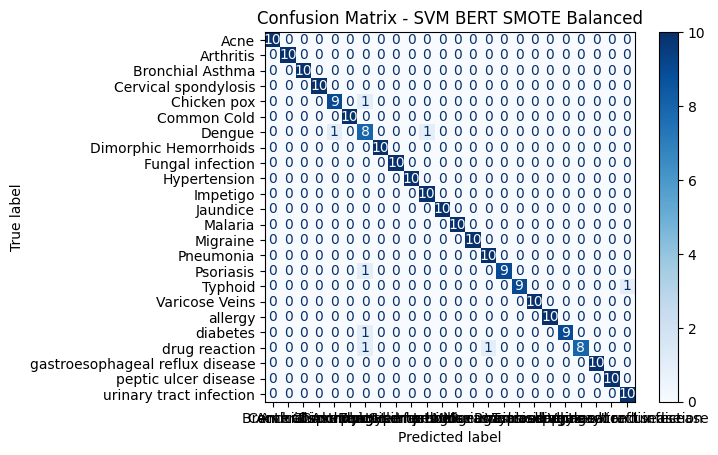

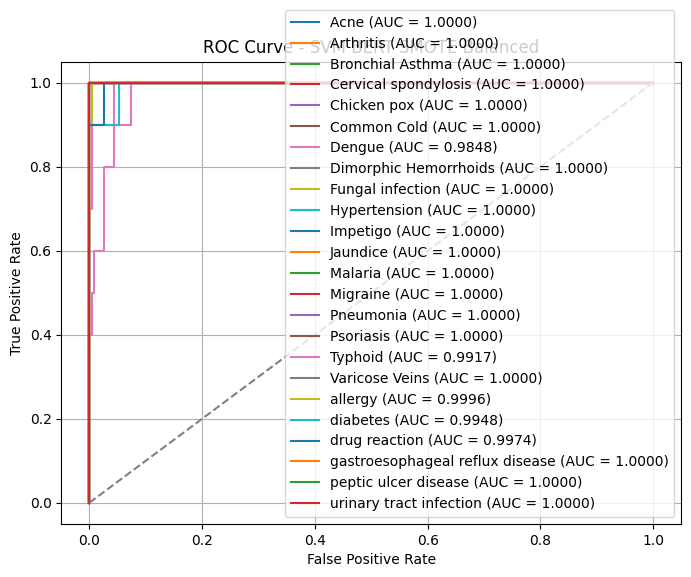

ROC AUC: 0.998677536231884


In [22]:
start_time = time.time()
svm_model_with_SMOTE_BERT.fit(X_train_resampled_BERT,Y_train_resampled_BERT)
end_time = time.time()
Y_pred = svm_model_with_SMOTE_BERT.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
svm_bert_balanced_scores_SMOTE.append(accuracy)
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print("\nClassification Report:\n")

print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=svm_model_with_SMOTE_BERT.decision_function(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="SVM BERT SMOTE Balanced"
)


## Logistic Regresion Model

##### Without SMOTE (TF-IDF)

###### Imbalanced dataset

Logistic Regression Accuracy: 0.7417
Training Duration: 0.10 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      0.90      0.95        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.15      1.00      0.26        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       1.00      0.20      0.33        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      0.90      0.95        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      0.70      0.82        10
                       Jaundice       1.00      1.00  

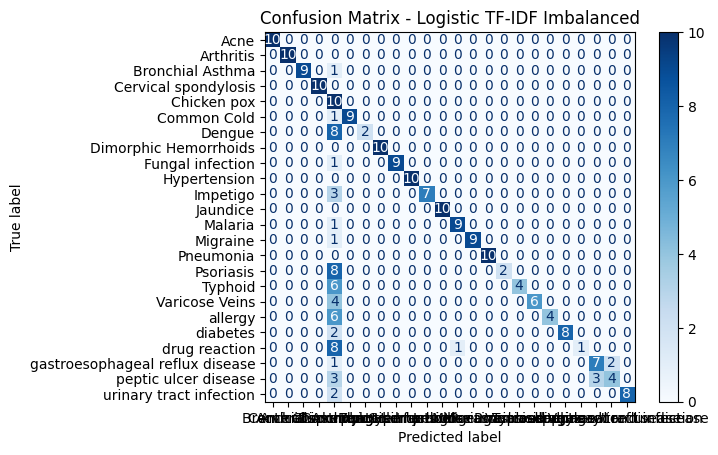

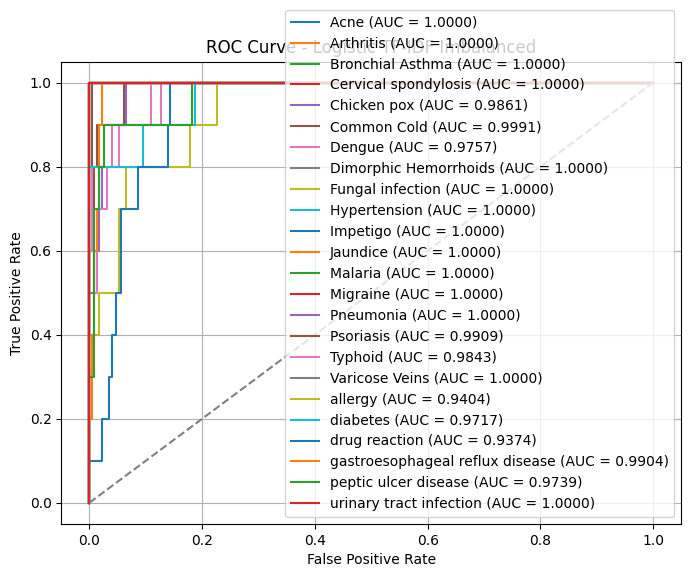

ROC AUC: 0.9895833333333334


In [23]:
start_time = time.time()
logistic_model_non_SMOTE.fit(X_train_vec_imbalanced, Y_train_imbalanced)
end_time = time.time()
Y_pred = logistic_model_non_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_tfidf_imbalanced_scores.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_non_SMOTE.predict_proba(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic TF-IDF Imbalanced"
)


Logistic Regression Accuracy: 0.9458
Training Duration: 0.15 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.80      0.89        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00  

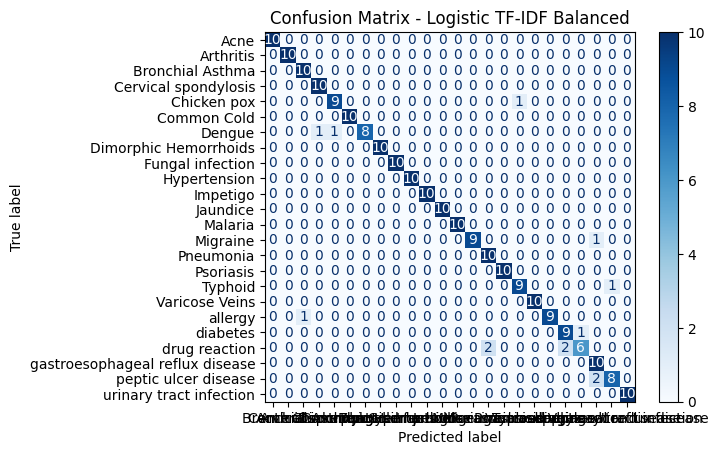

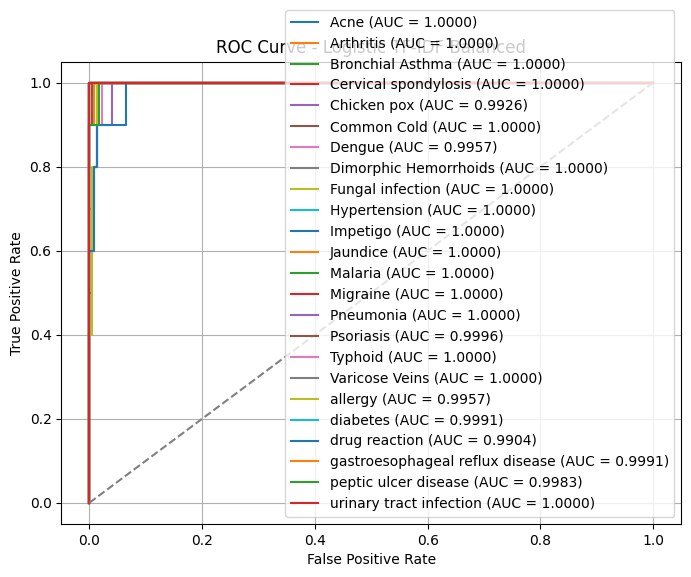

ROC AUC: 0.9987681159420291


In [24]:
start_time = time.time()
logistic_model_non_SMOTE.fit(X_train_vec, Y_train)
end_time = time.time()
Y_pred = logistic_model_non_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_tfidf_balanced_scores.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_non_SMOTE.predict_proba(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic TF-IDF Balanced"
)


##### Without SMOTE (BERT embedding)

###### Imbalanced

Logistic Regression Accuracy: 0.3375
Training Duration: 0.84 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      0.80      0.89        10
                      Arthritis       1.00      0.20      0.33        10
               Bronchial Asthma       0.75      0.30      0.43        10
           Cervical spondylosis       0.00      0.00      0.00        10
                    Chicken pox       0.16      1.00      0.28        10
                    Common Cold       0.00      0.00      0.00        10
                         Dengue       0.00      0.00      0.00        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.88      0.70      0.78        10
                   Hypertension       0.00      0.00      0.00        10
                       Impetigo       0.00      0.00      0.00        10
                       Jaundice       0.00      0.00  

c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

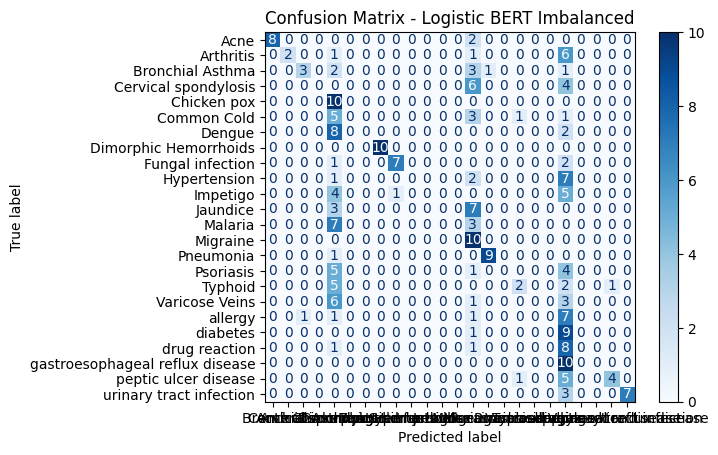

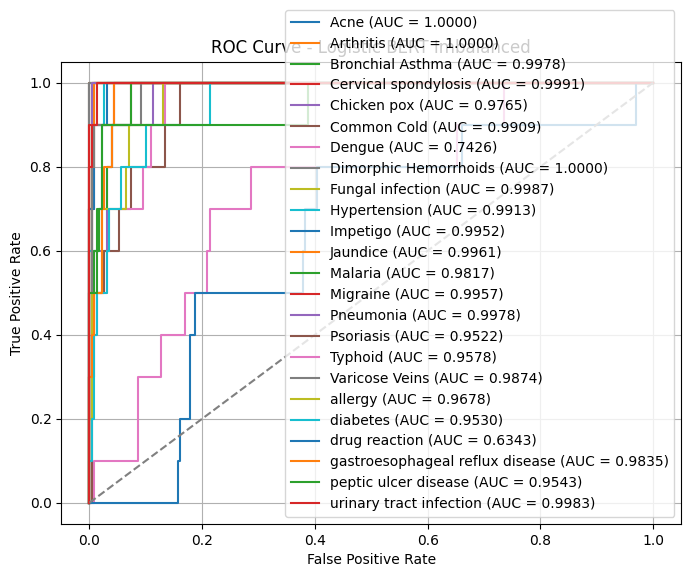

ROC AUC: 0.9605072463768116


In [25]:
start_time = time.time()
logistic_model_non_SMOTE_BERT.fit(X_train_embeddings_imbalanced, Y_train_imbalanced)
end_time = time.time()
Y_pred = logistic_model_non_SMOTE_BERT.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_bert_imbalanced_scores.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_non_SMOTE_BERT.predict_proba(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic BERT Imbalanced"
)


###### Balanced

Logistic Regression Accuracy: 0.9625
Training Duration: 0.75 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.62      0.80      0.70        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       1.00      1.00  

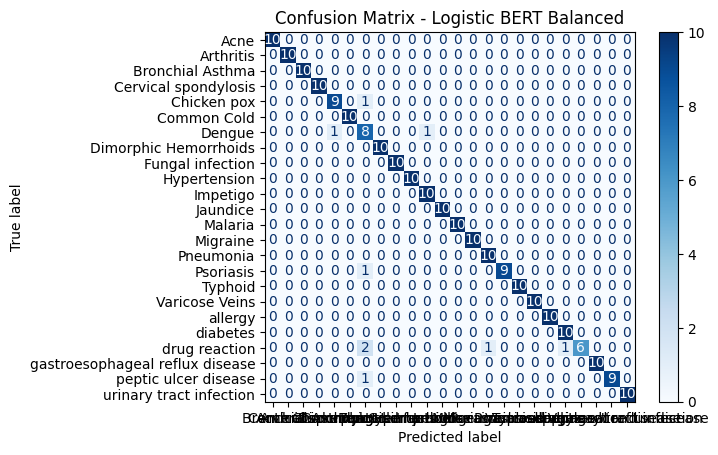

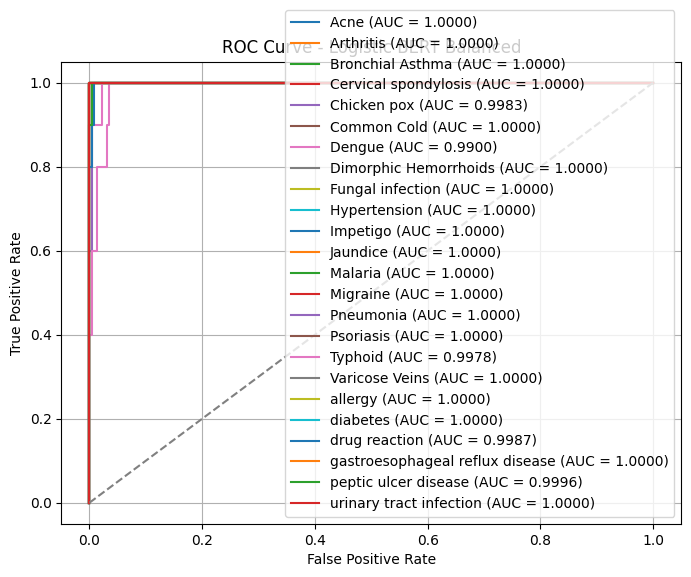

ROC AUC: 0.9993478260869565


In [26]:
start_time = time.time()
logistic_model_non_SMOTE_BERT.fit(X_train_embeddings, Y_train)
end_time = time.time()
Y_pred = logistic_model_non_SMOTE_BERT.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_bert_balanced_scores.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_non_SMOTE_BERT.predict_proba(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic BERT Balanced"
)


##### With SMOTE (TF-IDF)

###### Imabalanced dataset

Logistic Regression Accuracy: 0.8792
Training Duration: 0.13 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.59      1.00      0.74        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.88      0.70      0.78        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.91      1.00      0.95        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00  

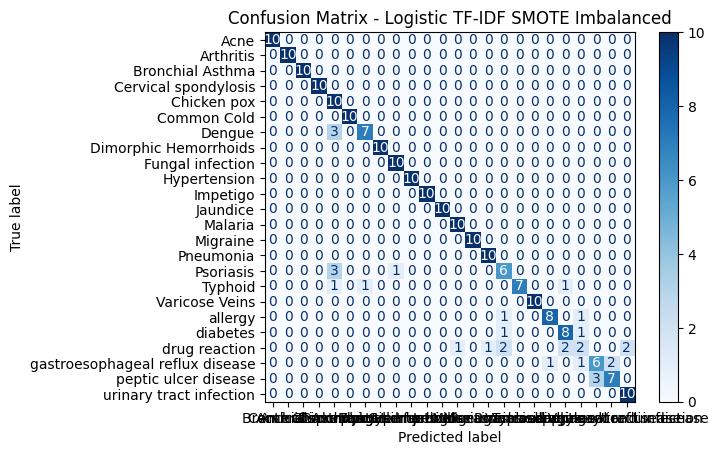

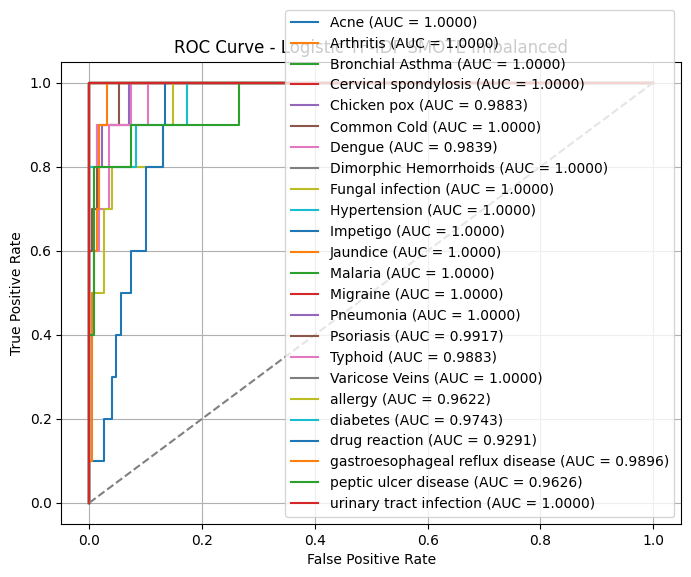

ROC AUC: 0.9904166666666666


In [27]:
start_time = time.time()
logistic_model_with_SMOTE.fit(X_train_resampled_imbalanced, Y_train_resampled_imbalanced)
end_time = time.time()
Y_pred = logistic_model_with_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_tfidf_imbalanced_scores_SMOTE.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_with_SMOTE.predict_proba(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic TF-IDF SMOTE Imbalanced"
)


###### Balaanced dataset

Logistic Regression Accuracy: 0.9417
Training Duration: 0.21 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.70      0.82        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00  

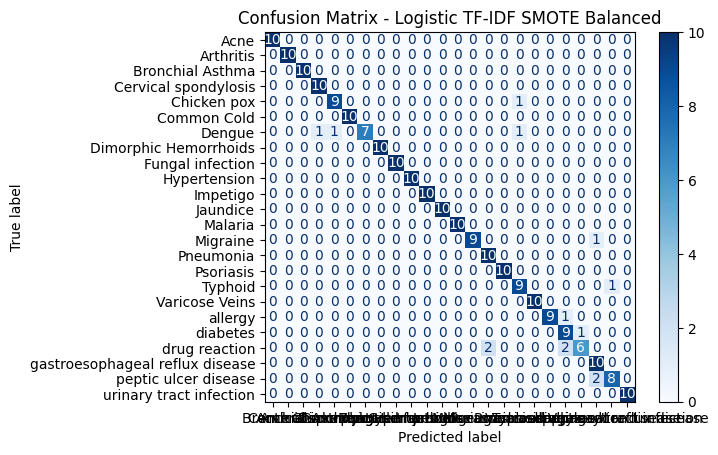

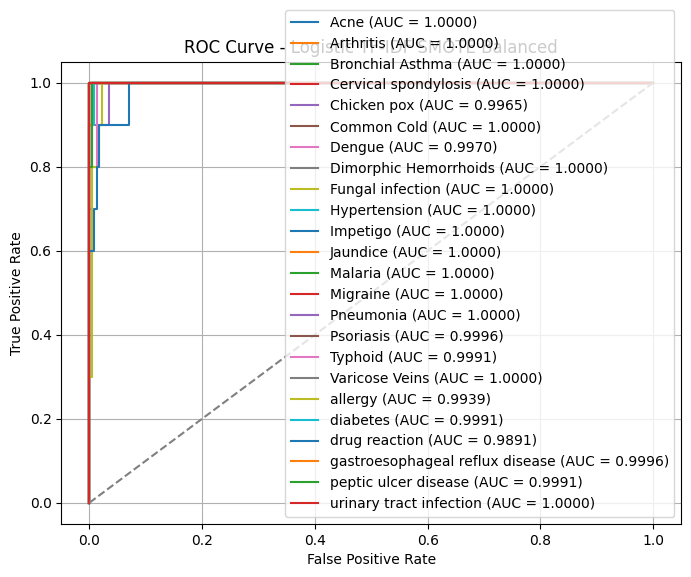

ROC AUC: 0.9988768115942029


In [28]:
start_time = time.time()
logistic_model_with_SMOTE.fit(X_train_resampled, Y_train_resampled)
end_time = time.time()

Y_pred = logistic_model_with_SMOTE.predict(X_test_vec)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_tfidf_balanced_scores_SMOTE.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_with_SMOTE.predict_proba(X_test_vec),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic TF-IDF SMOTE Balanced"
)


##### With SMOTE (BERT Embedding)

###### Imbalanced

Logistic Regression Accuracy: 0.4792
Training Duration: 0.55 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      0.90      0.95        10
                      Arthritis       1.00      0.60      0.75        10
               Bronchial Asthma       1.00      0.50      0.67        10
           Cervical spondylosis       1.00      0.20      0.33        10
                    Chicken pox       0.31      0.90      0.46        10
                    Common Cold       0.00      0.00      0.00        10
                         Dengue       0.00      0.00      0.00        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.62      1.00      0.77        10
                   Hypertension       0.83      0.50      0.62        10
                       Impetigo       1.00      0.20      0.33        10
                       Jaundice       1.00      0.90  

c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MS1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

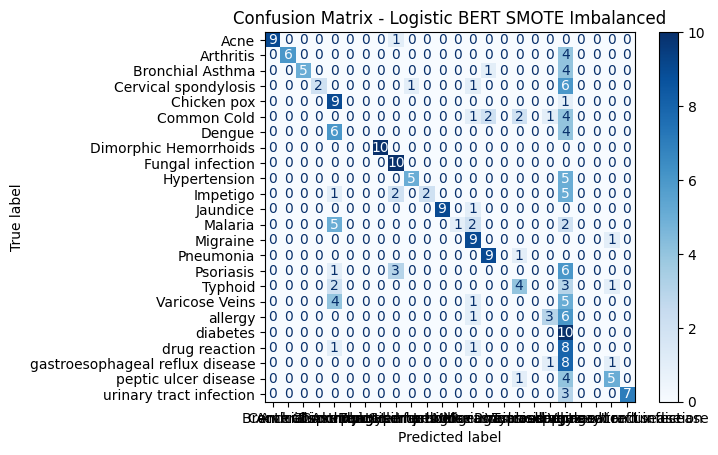

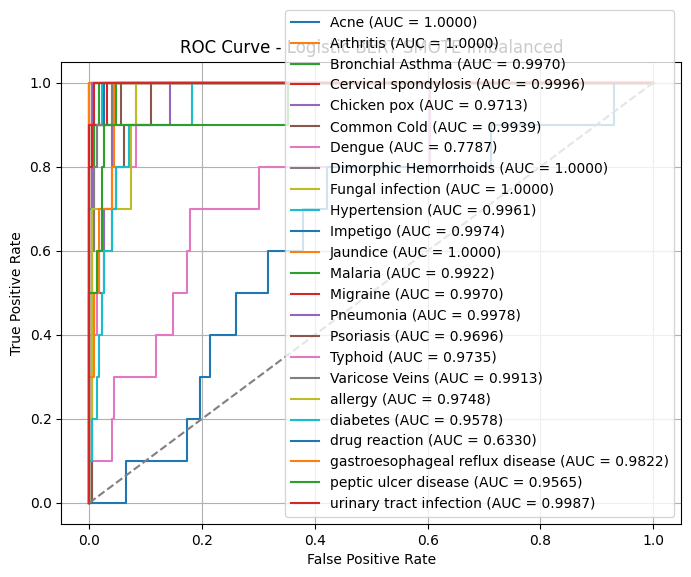

ROC AUC: 0.9649275362318841


In [29]:
start_time = time.time()
logistic_model_non_SMOTE.fit(X_train_resampled_BERT_imbalanced, Y_train_resampled_BERT_imbalanced)
end_time = time.time()

Y_pred = logistic_model_non_SMOTE.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_bert_imbalanced_scores_SMOTE.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_non_SMOTE.predict_proba(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic BERT SMOTE Imbalanced"
)


###### Balanced

Logistic Regression Accuracy: 0.9625
Training Duration: 0.72 seconds
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.57      0.80      0.67        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       1.00      1.00  

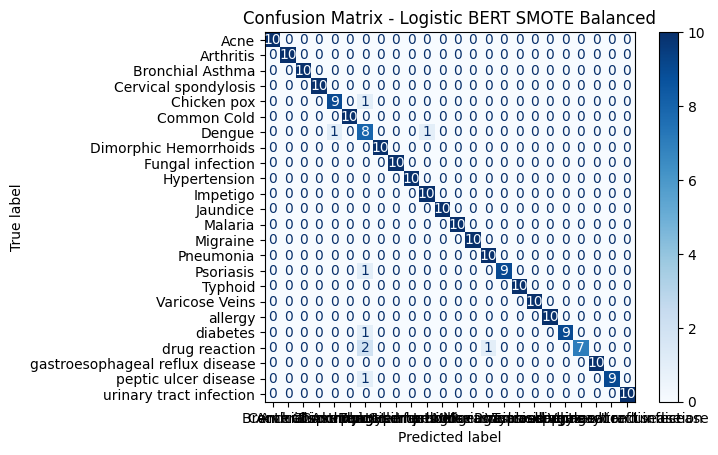

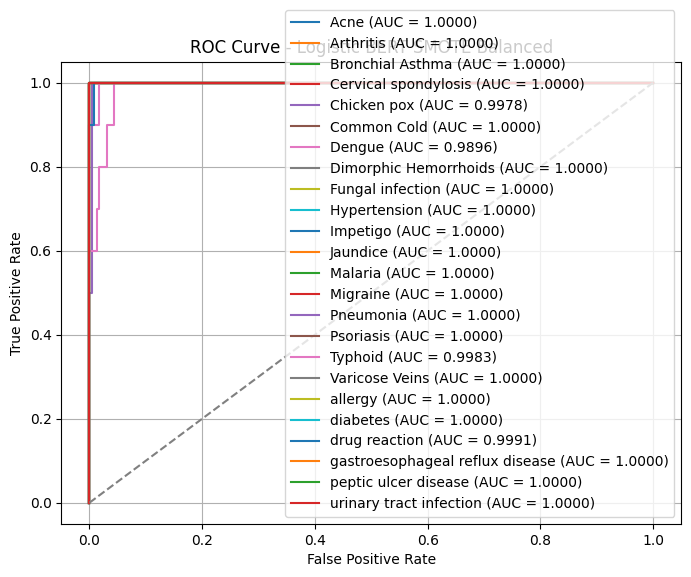

ROC AUC: 0.9993659420289855


In [30]:
start_time = time.time()
logistic_model_non_SMOTE.fit(X_train_resampled_BERT, Y_train_resampled_BERT)
end_time = time.time()

Y_pred = logistic_model_non_SMOTE.predict(X_test_embeddings)
accuracy = accuracy_score(Y_test, Y_pred)
logistic_bert_balanced_scores_SMOTE.append(accuracy)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Training Duration: {end_time - start_time:.2f} seconds")
print(classification_report(Y_test, Y_pred))
print_evaluation(
    Y_test,
    Y_pred,
    y_score=logistic_model_non_SMOTE.predict_proba(X_test_embeddings),
    labels=np.unique(np.concatenate([Y_test, Y_pred])),
    model_name="Logistic BERT SMOTE Balanced"
)


## BERT Model

In [31]:
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = TextDataset(X_train_bert.tolist(), Y_train_encoded, tokenizer)
test_dataset = TextDataset(X_test_bert.tolist(), Y_test_encoded, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

num_classes = len(label_encoder.classes_)
bert_classifier = BertClassifier(base_model, num_classes)
bert_classifier.to(device)

optimizer_adamw = AdamW(bert_classifier.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(bert_classifier.parameters(),lr=2e-5)
epochs = 4
total_t = 0
for epoch in range(epochs):
    start_time = time.time()
    print("Started epoch:", epoch+1)
    bert_classifier.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer_adamw.zero_grad()
        outputs = bert_classifier(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer_adamw.step()
        total_loss += loss.item()
        
    end_time = time.time()
    epoch_duration = end_time - start_time
    total_t = total_t + epoch_duration
    print(f'Epoch {epoch+1}, Loss: {total_loss / len(train_loader)}, Duration: {epoch_duration:.2f} seconds')
print(f"total time : {total_t}")
print('BERT training completed.')

Started epoch: 1
Epoch 1, Loss: 2.738721885283788, Duration: 366.91 seconds
Started epoch: 2
Epoch 2, Loss: 1.1985673040151597, Duration: 369.00 seconds
Started epoch: 3
Epoch 3, Loss: 0.4509060728053252, Duration: 335.11 seconds
Started epoch: 4
Epoch 4, Loss: 0.20392066066463788, Duration: 356.12 seconds
total time : 1427.1417837142944
BERT training completed.


In [32]:
bert_classifier.eval()

predictions = []
true_labels = []
probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_classifier(input_ids, attention_mask)
        probs_batch = torch.softmax(outputs, dim=1).cpu().numpy()

        _, preds = torch.max(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        probs.extend(probs_batch)
predicted_labels = label_encoder.inverse_transform(predictions)
true_labels_decoded = label_encoder.inverse_transform(true_labels)
for i in range(5):
    print("Text:", X_test_bert.iloc[i])
    print("True Label:", true_labels_decoded[i])
    print("Predicted:", predicted_labels[i])
    print()

Text: i've been experiencing chills, feel really exhausted, and my cough just won't go away. when i cough, my chest aches and my heart is pounding. it's a disgusting brownish hue, the mucous i'm coming up.
True Label: Pneumonia
Predicted: Pneumonia

Text: i've had intense itching all over my body, accompanied by chills and vomiting. my fever is really high and i've been sweating excessively. i also have a headache and feel nauseous. my muscles are really painful.
True Label: Malaria
Predicted: Malaria

Text: i have been feeling extremely tired and fatigued, and i have no energy to do anything. the fatigue is so severe that i struggle to get out of bed. i have noticed small rash on my arms and legs.
True Label: Dengue
Predicted: Dengue

Text: i'm having a lot of trouble with my bowel movements lately. it's hard to go and it hurts when i do. my anus is really sore and it's been bleeding when i go. it's really painful and i'm really uncomfortable.
True Label: Dimorphic Hemorrhoids
Predict


=== Evaluation for BERT Classifier ===
Accuracy: 0.9666666666666667
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       0.91      1.00      0.95        10
                         Dengue       0.90      0.90      0.90        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00  

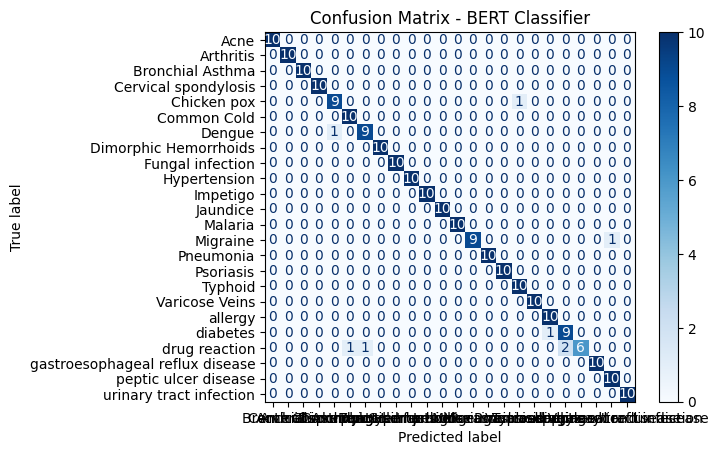

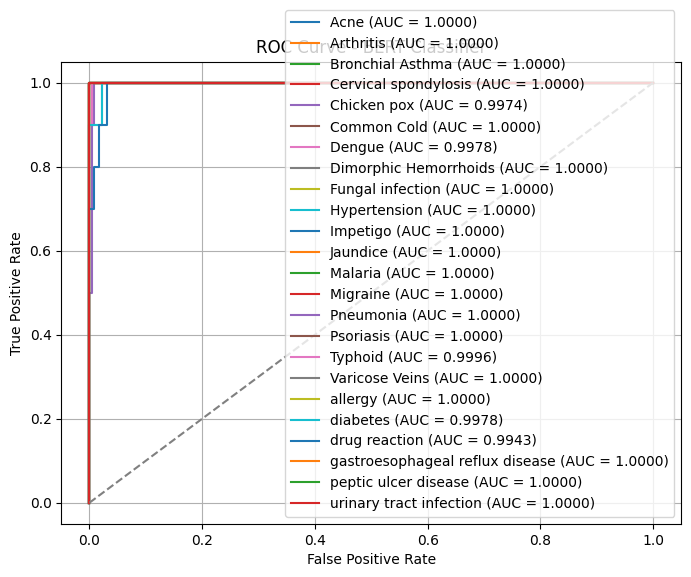

ROC AUC: 0.9994565217391305


In [33]:
print_evaluation(
    true_labels_decoded,
    predicted_labels,
    y_score=np.array(probs),
    labels=label_encoder.classes_,
    model_name="BERT Classifier"
)

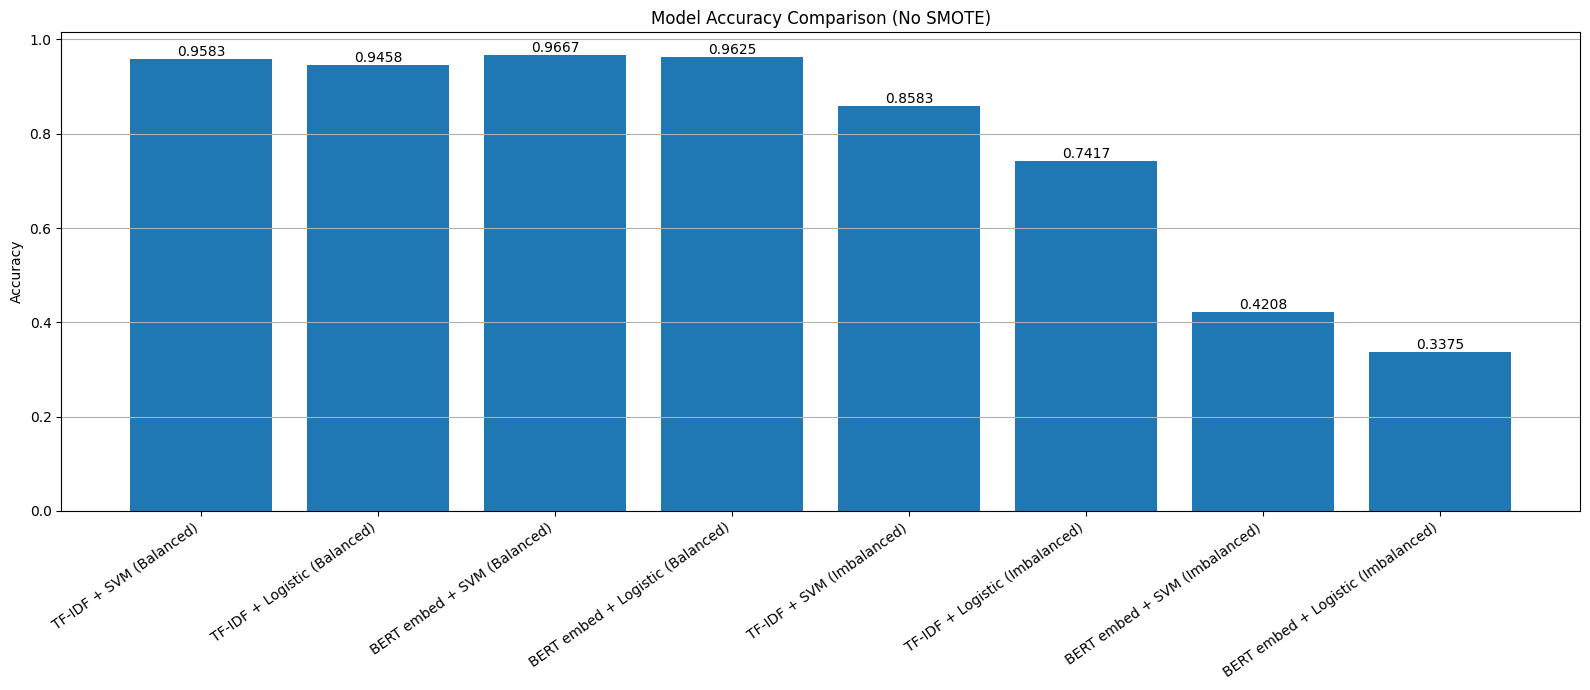

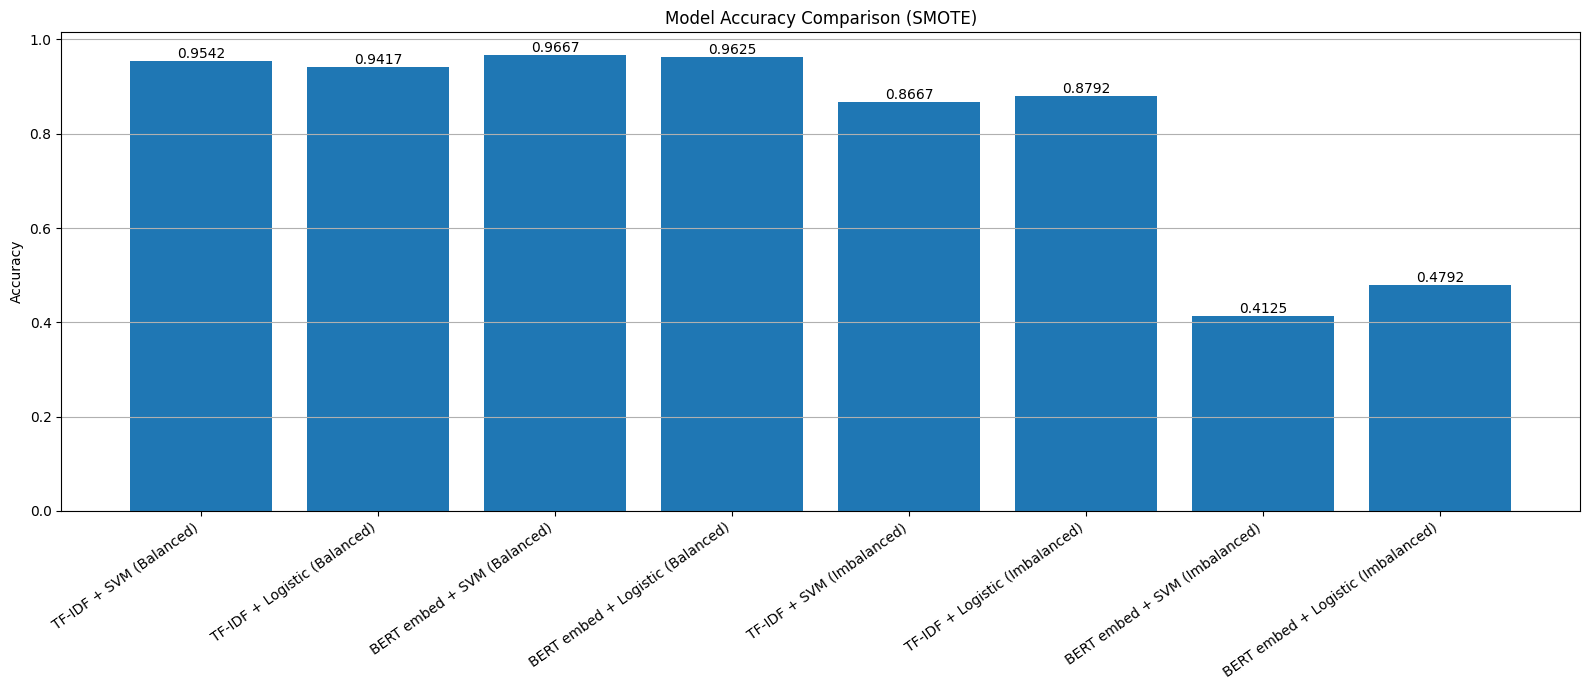

In [34]:
import matplotlib.pyplot as plt

# ==========================================
# NON-SMOTE BAR PLOT
# ==========================================

labels_non_smote = []
accuracies_non_smote = []

for key, value in results.items():

    if len(value) > 0:

        labels_non_smote.append(key)
        accuracies_non_smote.append(value[-1])

plt.figure(figsize=(16, 7))

bars = plt.bar(labels_non_smote, accuracies_non_smote)

# Add exact values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=35, ha='right')

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (No SMOTE)")

plt.grid(axis='y')

plt.tight_layout()
plt.show()


# ==========================================
# SMOTE BAR PLOT
# ==========================================

labels_smote = []
accuracies_smote = []

for key, value in results_SMOTE.items():

    if len(value) > 0:

        labels_smote.append(key)
        accuracies_smote.append(value[-1])

plt.figure(figsize=(16, 7))

bars = plt.bar(labels_smote, accuracies_smote)

# Add exact values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=35, ha='right')

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (SMOTE)")

plt.grid(axis='y')

plt.tight_layout()
plt.show()

## Saving bert model

In [35]:
import joblib

# =========================
# Save Model
# =========================

MODEL_SAVE_PATH = "bert_classifier_normalized_reproducable.pth"
TOKENIZER_SAVE_PATH = "bert_tokenizer_normalized_reproducable"
LABEL_ENCODER_PATH = "label_encoder_normalize_reproducabled.pkl"

# Save PyTorch model weights
torch.save(bert_classifier.state_dict(), MODEL_SAVE_PATH)

# Save tokenizer
tokenizer.save_pretrained(TOKENIZER_SAVE_PATH)

# Save label encoder
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

print("Model saved successfully.")

Model saved successfully.
